In [1]:
!pip install optuna
!pip install shap

In [2]:
#Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.INFO)

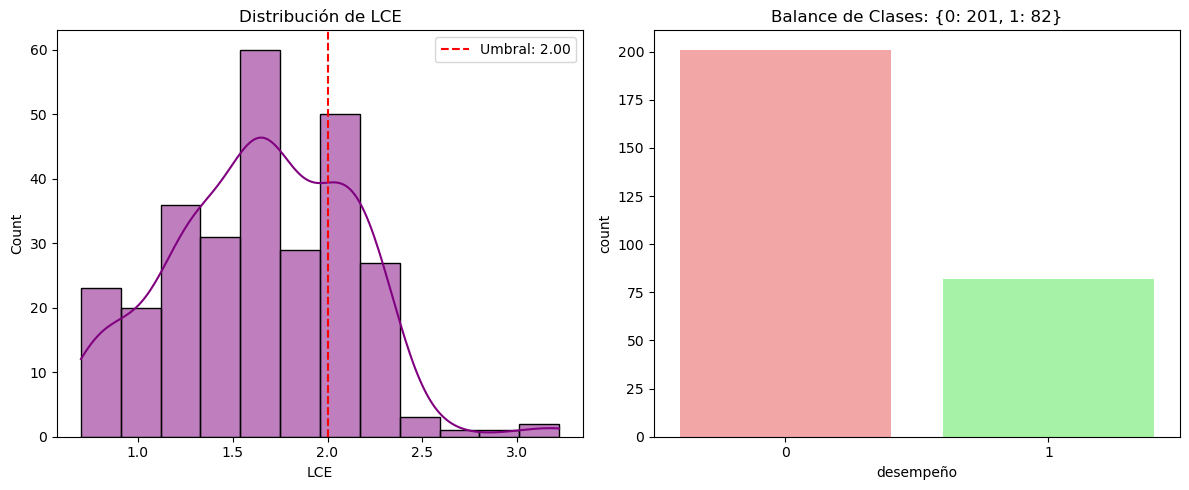

Dimensiones Train: (226, 13)
Dimensiones Test:  (57, 13)


In [3]:
ruta_archivo = r"C:\Users\Sergi\Desktop\Investigacion de materiales\Codigo definitivo\bdelectrolitos.csv"

df = pd.read_csv(ruta_archivo)
df = df.drop_duplicates()
df = df.sample(frac=1, random_state=22).reset_index(drop=True)

#Umbral y Variable Objetivo
UMBRAL = 2 # 2 es para 99% de Eficiencia Coulombica
df["desempeño"] = (df["LCE"] >= UMBRAL).astype(int)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=df, x="LCE", kde=True, color="purple", ax=axes[0])
axes[0].axvline(UMBRAL, color='red', linestyle='--', label=f'threshold: {UMBRAL:.2f}')
axes[0].set_title("LCE Distribution")
axes[0].legend()

#Balance de Clases
conteo = df["desempeño"].value_counts()
sns.countplot(x="desempeño", data=df, palette=["#ff9999", "#99ff99"], ax=axes[1])
axes[1].set_title(f"Class Balance: {conteo.to_dict()}")
axes[1].set_xlabel("Performance Level")  # Nuevo nombre del eje X
plt.tight_layout()
plt.show()

#Separar Datos
cols_drop = ["Electrolyte", "CE", "LCE", "desempeño"]
X = df.drop(columns=[c for c in cols_drop if c in df.columns])
y = df["desempeño"]
feature_names = X.columns.tolist()

#Split estratificado para mantener proporcion de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Dimensiones Train: {X_train.shape}")
print(f"Dimensiones Test:  {X_test.shape}")
#guardar las curvas ROC de todos los modelos
resultados_roc = {}

In [10]:
fig.savefig("distribucion_lce.png", dpi=300, bbox_inches="tight")

VERIFICACIÓN DE PROPORCIONES
            Train %    Test %
desempeño                    
0          0.712389  0.701754
1          0.287611  0.298246
Las proporciones están balanceadas entre sets.
VERIFICACIÓN VISUAL PCA 2D


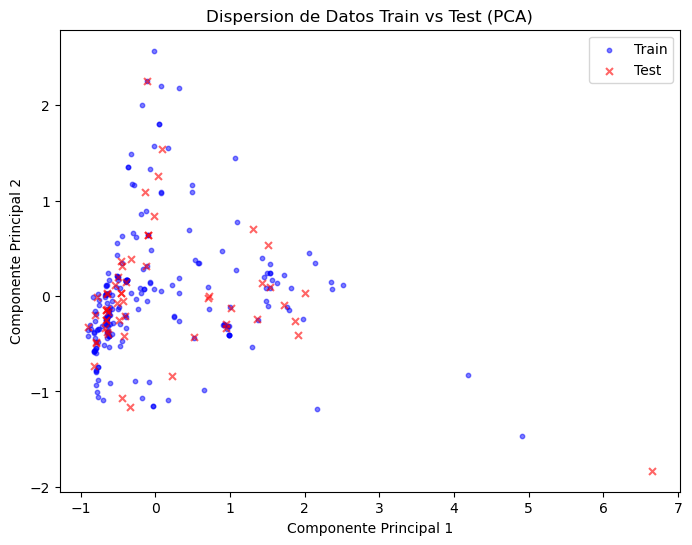

Interpretación: Los puntos rojos (Test) deben estar dispersos ENTRE los azules (Train).
Si ves los rojos agrupados en una isla lejana, la partición está sesgada.
COMPARACION DE DISTRIBUCIONES


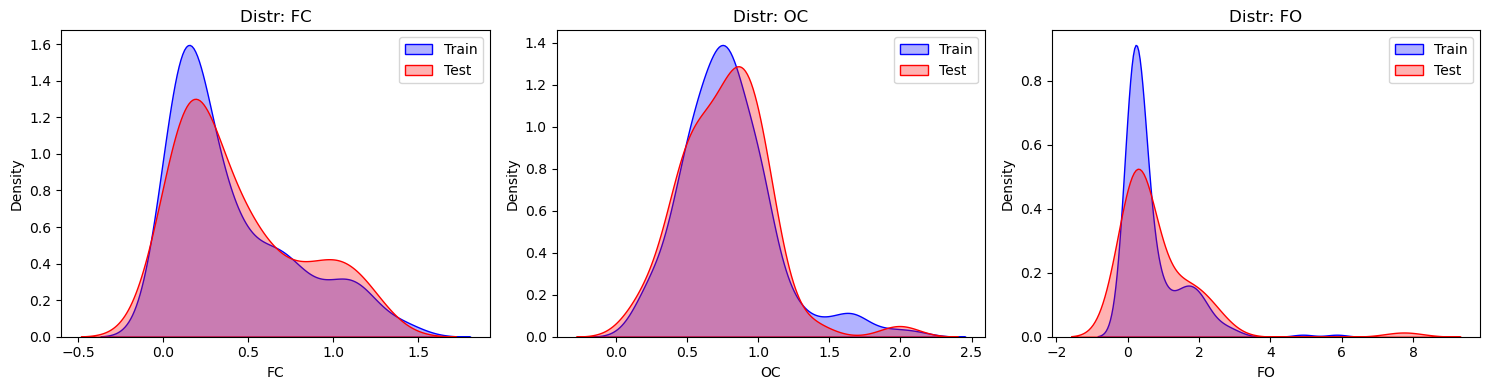

In [11]:
from sklearn.decomposition import PCA

def auditar_particion(X_train, y_train, X_test, y_test):
    print("VERIFICACIÓN DE PROPORCIONES")
    prop_train = y_train.value_counts(normalize=True)
    prop_test = y_test.value_counts(normalize=True)
    
    comp = pd.DataFrame({"Train %": prop_train, "Test %": prop_test})
    print(comp)
    
    # Alerta si hay mucha diferencia (> 5%)
    if abs(prop_train[1] - prop_test[1]) > 0.05:
        print("Las proporciones de clases son muy diferentes.")
    else:
        print("Las proporciones están balanceadas entre sets.")

    print("VERIFICACIÓN VISUAL PCA 2D")
    #Reducir todas las features a 2 dimensiones para ver si se mezclan
    pca = PCA(n_components=2)
    #Entrenamos PCA con todo el conjunto para tener una referencia
    X_all_pca = pca.fit_transform(pd.concat([X_train, X_test]))
    train_pca = X_all_pca[:len(X_train)]
    test_pca = X_all_pca[len(X_train):]
    
    plt.figure(figsize=(8, 6))
    plt.scatter(train_pca[:, 0], train_pca[:, 1], c='blue', alpha=0.5, label='Train', s=10)
    plt.scatter(test_pca[:, 0], test_pca[:, 1], c='red', alpha=0.6, label='Test', s=25, marker='x')
    plt.title("Dispersion de Datos Train vs Test (PCA)")
    plt.legend()
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.savefig("PCA",dpi=300, bbox_inches="tight")
    plt.show()
    print("COMPARACION DE DISTRIBUCIONES")
    # Tomamos las 3 primeras columnas numéricas para comparar
    cols_to_plot = X_train.select_dtypes(include=np.number).columns[:3] 
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, col in enumerate(cols_to_plot):
        sns.kdeplot(X_train[col], ax=axes[i], color='blue', label='Train', fill=True, alpha=0.3)
        sns.kdeplot(X_test[col], ax=axes[i], color='red', label='Test', fill=True, alpha=0.3)
        axes[i].set_title(f"Distr: {col}")
        axes[i].legend()
    plt.tight_layout()
    plt.show()

#EJECUTAR
auditar_particion(X_train, y_train, X_test, y_test)

In [ ]:
fig.savefig("distribucion_lce.png", dpi=300, bbox_inches="tight")

In [17]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
#nombres de las nuevas variables x1^2, x1*x2
feature_names_poly = poly.get_feature_names_out(X.columns)
print(f"Nuevas dimensiones con polinomios (Train): {X_train_poly.shape}")

Nuevas dimensiones con polinomios (Train): (226, 104)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

#Escalado OBLIGATORIO para Lasso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

#Aplicar Lasso (Logistic Regression con penalización L1)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=.5, random_state=42)
lasso.fit(X_train_scaled, y_train)
coeficientes = pd.Series(lasso.coef_[0], index=feature_names_poly)
importantes = coeficientes.abs().sort_values(ascending=False)
#Seleccionar las 20 más importantes
top_20_features = importantes.head(20).index.tolist()
X_train_final = pd.DataFrame(X_train_poly, columns=feature_names_poly)[top_20_features]
X_test_final = pd.DataFrame(X_test_poly, columns=feature_names_poly)[top_20_features]

print(f"Variables seleccionadas: {top_20_features}")
print(f"Nueva forma de X_train: {X_train_final.shape}")
n_eliminadas = (coeficientes == 0).sum()
print(f"Lasso eliminó {n_eliminadas} variables de las {len(coeficientes)} originales.")

Variables seleccionadas: ['sO C', 'FO sC', 'aO aC', 'aF C', 'OC^2', 'C', 'FO aO', 'FO C', 'sF aF', 'O', 'aO', 'sO', 'aC', 'FC^2', 'FC OC', 'sC', 'FC InOr', 'aF', 'FC sF', 'FC aF']
Nueva forma de X_train: (226, 20)
Lasso eliminó 95 variables de las 104 originales.


In [31]:
print(X_train_final)

         sO C     FO sC  aO aC      aF C      OC^2      C     FO aO      FO C  \
0    0.067080  0.086580    0.0  0.010400  0.988036  0.260  0.000000  0.086580   
1    0.022500  0.073200    0.0  0.005400  0.062500  0.300  0.000000  0.073200   
2    0.067080  0.086320    0.0  0.010400  0.984064  0.260  0.000000  0.086320   
3    0.020000  0.044800    0.0  0.008000  0.819025  0.200  0.018144  0.044800   
4    0.048400  0.085360    0.0  0.011660  2.208196  0.220  0.041516  0.085360   
..        ...       ...    ...       ...       ...    ...       ...       ...   
221  0.025812  0.464377    0.0  0.004302  0.362404  0.239  0.069948  0.464377   
222  0.014553  0.048114    0.0  0.003564  0.061009  0.297  0.003888  0.048114   
223  0.008679  0.075744    0.0  0.005786  0.087025  0.263  0.012960  0.075744   
224  0.021084  0.577802    0.0  0.004016  0.214369  0.251  0.073664  0.577802   
225  0.025546  0.453803    0.0  0.004579  0.356409  0.241  0.069671  0.453803   

        sF aF      O     aO

In [32]:
def evaluar_modelo_completo(nombre, modelo, X_train, y_train, X_test, y_test):
    """
    Entrena el modelo final con los mejores parámetros, 
    imprime métricas de Train y Test, y grafica Matriz y ROC.
    """
    #Entrenar modelo final
    modelo.fit(X_train, y_train)
    
    #Predicciones Train
    y_pred_tr = modelo.predict(X_train)
    y_prob_tr = modelo.predict_proba(X_train)[:, 1]
    #Predicciones Test
    y_pred_te = modelo.predict(X_test)
    y_prob_te = modelo.predict_proba(X_test)[:, 1]
    #Métricas
    #-------------------------------------
    print(f"\nRESULTADOS: {nombre}")
    print("\nTRAIN (Entrenamiento)")
    print(f"AUC: {roc_auc_score(y_train, y_prob_tr):.4f}")
    print(f"Accuracy: {accuracy_score(y_train, y_pred_tr):.4f}")
    print(f"F1-Score: {f1_score(y_train, y_pred_tr):.4f}")
    #-------------------------------------
    print("\nTEST (Prueba)")
    print(f"AUC: {roc_auc_score(y_test, y_prob_te):.4f}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_te):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_te):.4f}")
    print("-" * 50)
    print("Reporte de Clasificación (Test):")
    print(classification_report(y_test, y_pred_te))
    #-------------------------------------
    #Gráficos
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    #Matriz de Confusión
    sns.heatmap(confusion_matrix(y_test, y_pred_te), annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title(f'Matriz de Confusión - {nombre}')
    ax[0].set_ylabel('Realidad')
    ax[0].set_xlabel('Predicción')
    #Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob_te)
    roc_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_ylim([0.0, 1.05])
    ax[1].set_xlabel('Falsos Positivos')
    ax[1].set_ylabel('Verdaderos Positivos')
    ax[1].set_title(f'Curva ROC - {nombre}')
    ax[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()
    return modelo, y_prob_te

[I 2026-02-11 14:00:02,029] A new study created in memory with name: no-name-2e00df47-df3c-4789-8a4b-1c7a3171c4b6


OPTIMIZACIÓN RANDOM FOREST


[I 2026-02-11 14:00:07,575] Trial 0 finished with value: 0.8424894957983193 and parameters: {'n_estimators': 461, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 0.2600135212197987, 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8424894957983193.
[I 2026-02-11 14:00:10,325] Trial 1 finished with value: 0.831267507002801 and parameters: {'n_estimators': 201, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 0.5849867214500318, 'bootstrap': True, 'criterion': 'gini'}. Best is trial 0 with value: 0.8424894957983193.
[I 2026-02-11 14:00:13,539] Trial 2 finished with value: 0.831390056022409 and parameters: {'n_estimators': 290, 'max_depth': 10, 'min_samples_split': 19, 'min_samples_leaf': 5, 'max_features': 0.25470433087554367, 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8424894957983193.
[I 2026-02-11 14:00:15,746] Trial 3 finished with value: 0.8388567927170868 and par

MEJORES HIPERPARÁMETROS (Random Forest):

RESULTADOS: Random Forest Optimizado

TRAIN (Entrenamiento)
AUC: 0.9486
Accuracy: 0.8761
F1-Score: 0.8133

TEST (Prueba)
AUC: 0.9199
Accuracy: 0.8596
F1-Score: 0.7895
--------------------------------------------------
Reporte de Clasificación (Test):
              precision    recall  f1-score   support

           0       0.94      0.85      0.89        40
           1       0.71      0.88      0.79        17

    accuracy                           0.86        57
   macro avg       0.83      0.87      0.84        57
weighted avg       0.88      0.86      0.86        57



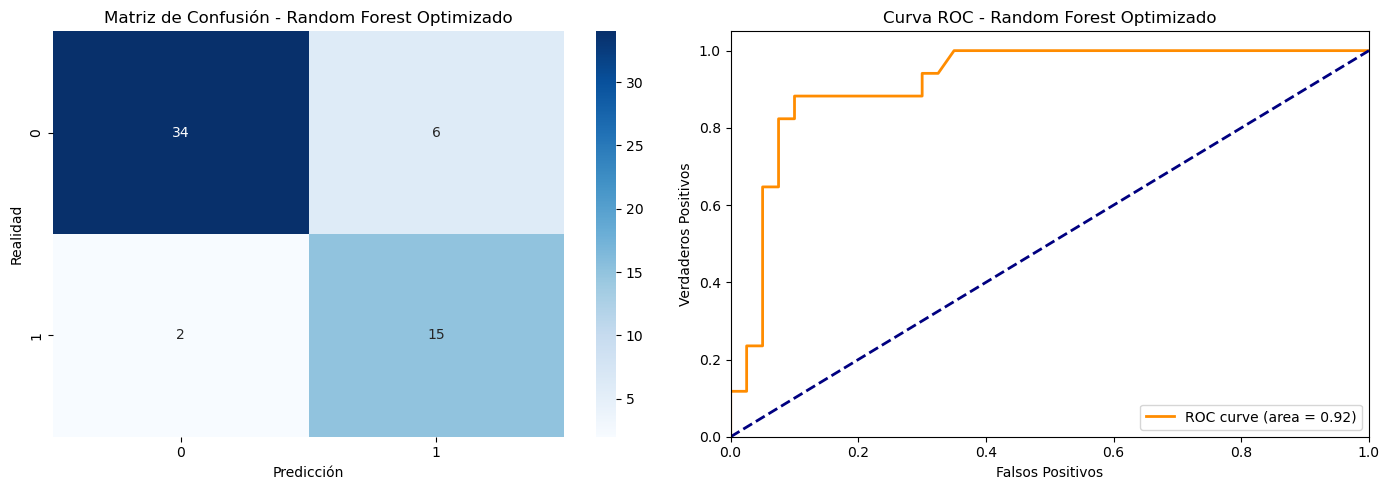


Generando explicación SHAP para Random Forest...
Formato detectado: Array 3D


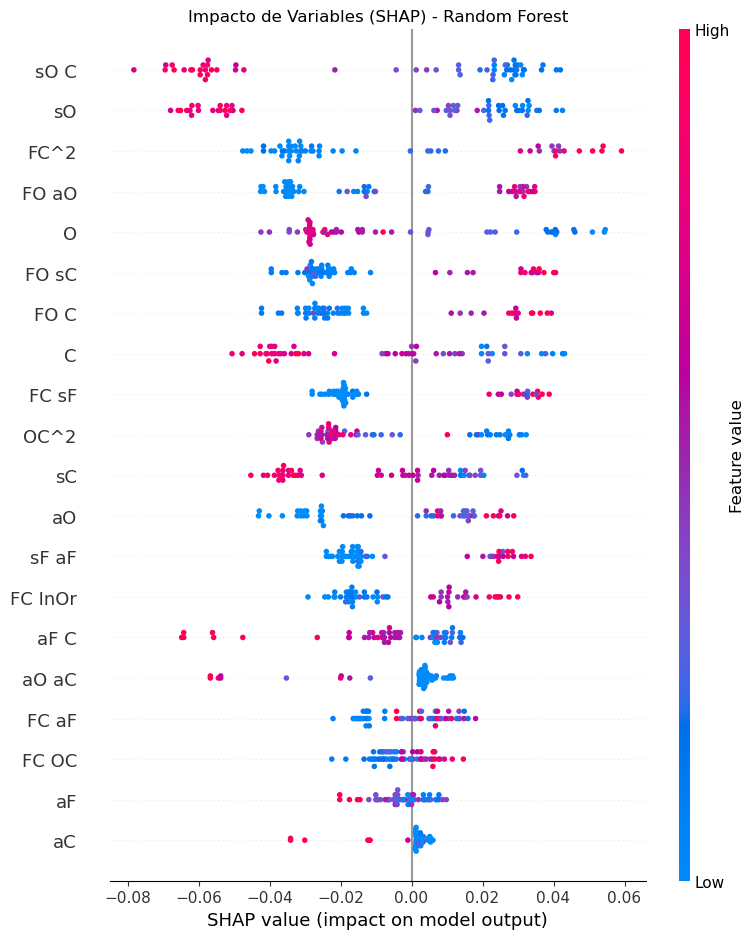

In [35]:
print("OPTIMIZACIÓN RANDOM FOREST")

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20), 
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_float('max_features', 0.1, 0.9),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1}
    
    model = RandomForestClassifier(**params)
    # Validacióon con variables seleccionadas
    scores = cross_val_score(model, X_train_final, y_train, cv=10, scoring='roc_auc')
    return scores.mean()
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=200) 
print("MEJORES HIPERPARÁMETROS (Random Forest):")
mejores_params_rf = study_rf.best_params
mejores_params_rf.update({'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1})
#Pipeline Final
final_pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(**mejores_params_rf))
])
#Evaluar
modelo_rf_entrenado, probs_rf = evaluar_modelo_completo(
    "Random Forest Optimizado", 
    final_pipeline_rf, 
    X_train_final, y_train, 
    X_test_final, y_test
)

resultados_roc["Random Forest"] = probs_rf

#GRÁFICO SHAP
step_scaler = modelo_rf_entrenado.named_steps['scaler']
X_test_scaled = step_scaler.transform(X_test_final)
X_test_shap_df = pd.DataFrame(X_test_scaled, columns=X_test_final.columns)
explainer = shap.TreeExplainer(step_rf)
shap_values = explainer.shap_values(X_test_shap_df, check_additivity=False)
import numpy as np
if isinstance(shap_values, list):
    print("Lista (Sklearn estándar)")
    vals_to_plot = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    print("Array 3D")
    vals_to_plot = shap_values[:, :, 1]
else:
    print("Formato estándar")
    vals_to_plot = shap_values

#Graficar
plt.figure(figsize=(10, 6))
plt.title("Impacto de Variables (SHAP) - Random Forest")
shap.summary_plot(vals_to_plot, X_test_shap_df, show=False)
plt.show()

[I 2026-02-11 14:38:32,764] A new study created in memory with name: no-name-b7647342-268b-4426-bd64-b9d3eb3e28e7


OPTIMIZACIÓN XGBOOST


[I 2026-02-11 14:38:34,295] Trial 0 finished with value: 0.8227591036414565 and parameters: {'n_estimators': 1084, 'max_depth': 20, 'learning_rate': 0.023666784324842996, 'subsample': 0.5487977976972582, 'colsample_bytree': 0.9718161579239699, 'gamma': 3.7503949338228337}. Best is trial 0 with value: 0.8227591036414565.
[I 2026-02-11 14:38:34,828] Trial 1 finished with value: 0.8205663515406163 and parameters: {'n_estimators': 336, 'max_depth': 16, 'learning_rate': 0.14262847615270635, 'subsample': 0.52659882691975, 'colsample_bytree': 0.9821186377319979, 'gamma': 3.9490651300381607}. Best is trial 0 with value: 0.8227591036414565.
[I 2026-02-11 14:38:36,403] Trial 2 finished with value: 0.8308473389355742 and parameters: {'n_estimators': 1179, 'max_depth': 16, 'learning_rate': 0.0193955935939221, 'subsample': 0.8280277972640537, 'colsample_bytree': 0.5151252484169615, 'gamma': 2.4687244894126765}. Best is trial 2 with value: 0.8308473389355742.
[I 2026-02-11 14:38:37,402] Trial 3 fini

MEJORES HIPERPARÁMETROS (XGBoost):
{'n_estimators': 1895, 'max_depth': 6, 'learning_rate': 0.011975083658645332, 'subsample': 0.9614834956588891, 'colsample_bytree': 0.8961511428585627, 'gamma': 4.926738401402302}

RESULTADOS: XGBoost Optimizado

TRAIN (Entrenamiento)
AUC: 0.9411
Accuracy: 0.8717
F1-Score: 0.8000

TEST (Prueba)
AUC: 0.9551
Accuracy: 0.9123
F1-Score: 0.8649
--------------------------------------------------
Reporte de Clasificación (Test):
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        40
           1       0.80      0.94      0.86        17

    accuracy                           0.91        57
   macro avg       0.89      0.92      0.90        57
weighted avg       0.92      0.91      0.91        57



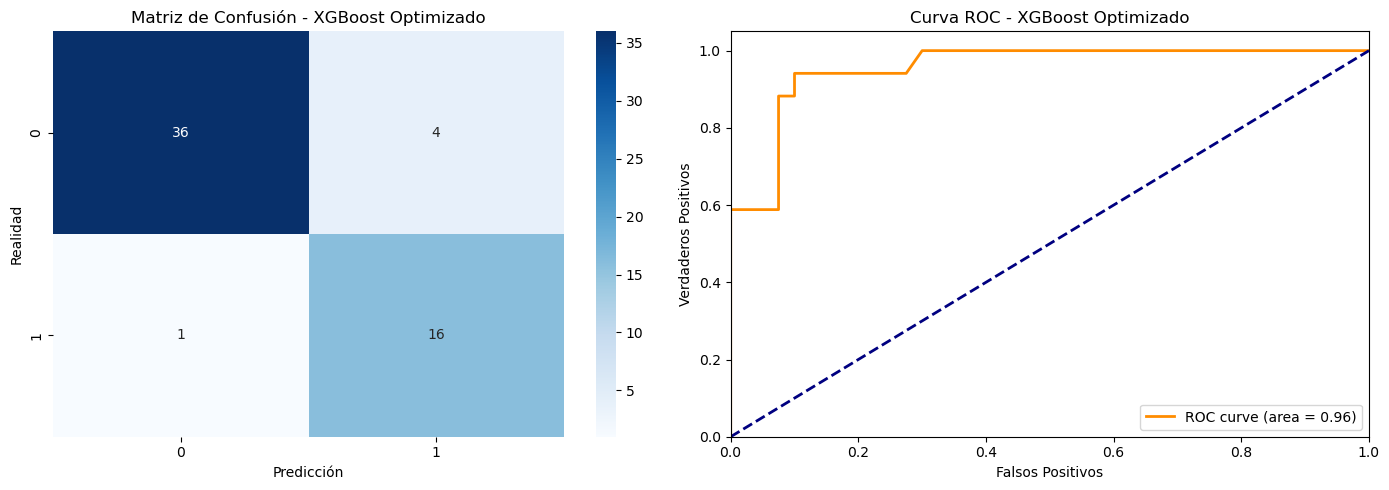


Generando explicación SHAP para XGBoost...


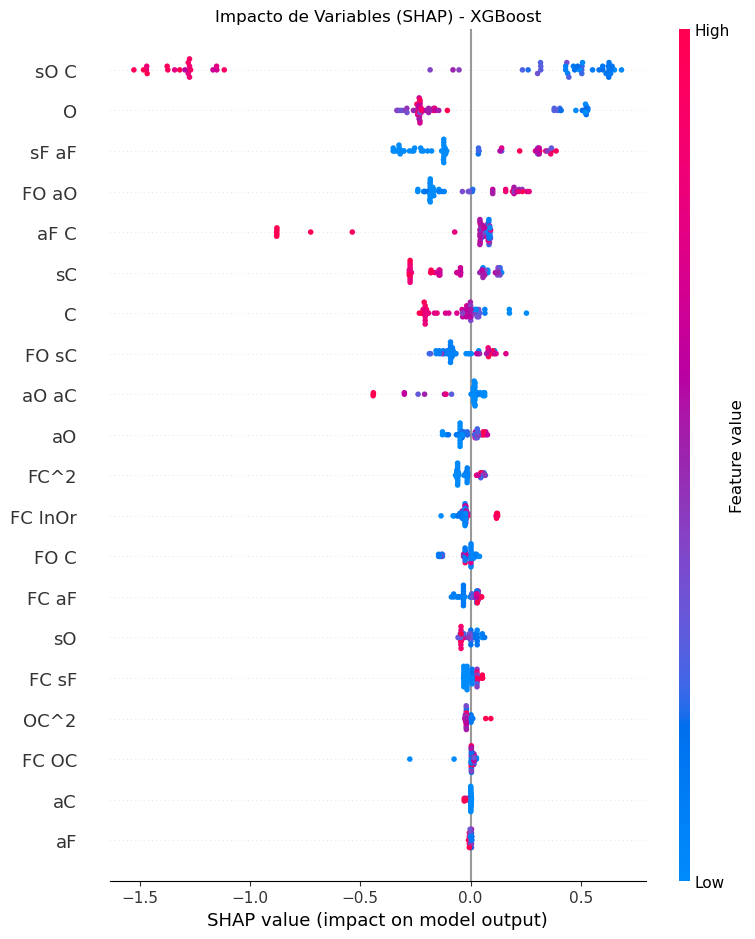

In [38]:
print("OPTIMIZACIÓN XGBOOST")

#ratio de desbalance para scale_pos_weight
ratio_desbalance = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 20), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': ratio_desbalance, 
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0 }
    clf = Pipeline([
        ('scaler', StandardScaler()), 
        ('xgb', XGBClassifier(**params))
    ])
    
    # Validación cruzada con las variables seleccionadas
    scores = cross_val_score(clf, X_train_final, y_train, cv=10, scoring='roc_auc')
    
    return scores.mean()

#Optuna
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=200) 

print("MEJORES HIPERPARÁMETROS (XGBoost):")
print(study_xgb.best_params)
best_params_xgb = study_xgb.best_params
best_params_xgb.update({
    'scale_pos_weight': ratio_desbalance, 
    'eval_metric': 'logloss', 
    'random_state': 42, 
    'n_jobs': -1,
    'verbosity': 0})
final_pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()), 
    ('xgb', XGBClassifier(**best_params_xgb))])

#Evaluar resultados usando las variables lasso
modelo_xgb_entrenado, probs_xgb = evaluar_modelo_completo(
    "XGBoost Optimizado", 
    final_pipeline_xgb, 
    X_train_final, y_train, 
    X_test_final, y_test
)
resultados_roc["XGBoost"] = probs_xgb

#GRAFICO SHAP XGBOOST
step_xgb = final_pipeline_xgb.named_steps['xgb']
step_scaler = final_pipeline_xgb.named_steps['scaler']
X_test_scaled = step_scaler.transform(X_test_final)
X_test_shap_df = pd.DataFrame(X_test_scaled, columns=X_test_final.columns)
explainer = shap.TreeExplainer(step_xgb)
shap_values = explainer.shap_values(X_test_shap_df)

#Graficar
plt.figure(figsize=(10, 6))
plt.title("Impacto de Variables (SHAP) - XGBoost")
shap.summary_plot(shap_values, X_test_shap_df, show=False)
plt.show()

[I 2026-02-11 14:46:37,093] A new study created in memory with name: no-name-6df8ec07-4cf2-47ef-ae16-cf27570cac99
[I 2026-02-11 14:46:37,251] Trial 0 finished with value: 0.8189163165266107 and parameters: {'n_neighbors': 18, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 0 with value: 0.8189163165266107.


OPTIMIZACIÓN KNN


[I 2026-02-11 14:46:37,305] Trial 1 finished with value: 0.8230698529411764 and parameters: {'n_neighbors': 6, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 1 with value: 0.8230698529411764.
[I 2026-02-11 14:46:37,437] Trial 2 finished with value: 0.8583464635854343 and parameters: {'n_neighbors': 28, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 2 with value: 0.8583464635854343.
[I 2026-02-11 14:46:37,565] Trial 3 finished with value: 0.8583464635854343 and parameters: {'n_neighbors': 28, 'weights': 'uniform', 'metric': 'minkowski'}. Best is trial 2 with value: 0.8583464635854343.
[I 2026-02-11 14:46:37,696] Trial 4 finished with value: 0.8081889005602241 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'metric': 'minkowski'}. Best is trial 2 with value: 0.8583464635854343.
[I 2026-02-11 14:46:37,749] Trial 5 finished with value: 0.8051995798319327 and parameters: {'n_neighbors': 4, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 2 with


MEJORES HIPERPARÁMETROS (KNN):
{'n_neighbors': 27, 'weights': 'uniform', 'metric': 'manhattan'}


RESULTADOS: KNN Optimizado

TRAIN (Entrenamiento)
AUC: 0.8652
Accuracy: 0.8186
F1-Score: 0.6372

TEST (Prueba)
AUC: 0.8993
Accuracy: 0.8421
F1-Score: 0.7273
--------------------------------------------------
Reporte de Clasificación (Test):
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        40
           1       0.75      0.71      0.73        17

    accuracy                           0.84        57
   macro avg       0.81      0.80      0.81        57
weighted avg       0.84      0.84      0.84        57



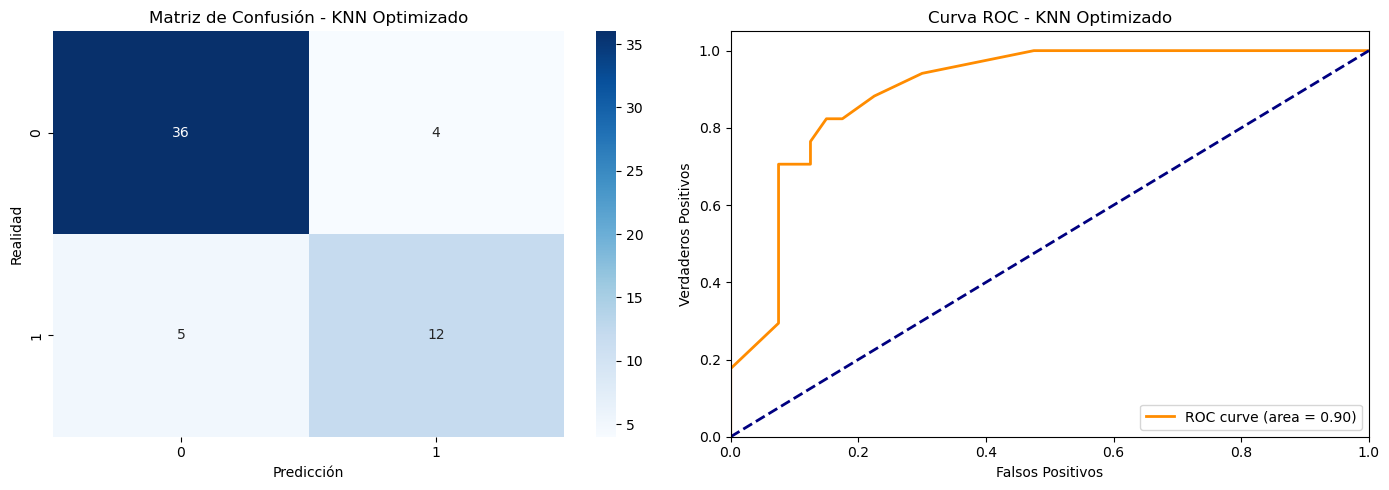

In [40]:
print("OPTIMIZACIÓN KNN")

def objective_knn(trial):
    #parámetros a probar
    n_neighbors = trial.suggest_int('n_neighbors', 3, 30)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])
    clf = Pipeline([
        ('scaler', StandardScaler()), 
        ('knn', KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            metric=metric,
            n_jobs=-1
        ))
    ])
    
    #Validacion cruzada variables Lasso
    scores = cross_val_score(clf, X_train_final, y_train, cv=10, scoring='roc_auc')  
    return scores.mean()

#Optuna
study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=200) 
print("MEJORES HIPERPARÁMETROS (KNN):")
print(study_knn.best_params)

#ENTRENAMIENTO FINAL
best_params_knn = study_knn.best_params
final_pipeline_knn = Pipeline([
    ('scaler', StandardScaler()), 
    ('knn', KNeighborsClassifier(
        n_neighbors=best_params_knn['n_neighbors'],
        weights=best_params_knn['weights'],
        metric=best_params_knn['metric'],
        n_jobs=-1
    ))
])

#Evaluar
modelo_knn_entrenado, probs_knn = evaluar_modelo_completo(
    "KNN Optimizado", 
    final_pipeline_knn, 
    X_train_final, y_train, 
    X_test_final, y_test
)
resultados_roc["KNN"] = probs_knn

[I 2026-02-11 14:46:52,542] A new study created in memory with name: no-name-b6d17ed7-59b1-49f3-b7b8-a2ce596b5774
[I 2026-02-11 14:46:52,613] Trial 0 finished with value: 0.8498249299719888 and parameters: {'C': 95.06074215446291, 'penalty': 'l2'}. Best is trial 0 with value: 0.8498249299719888.
[I 2026-02-11 14:46:52,717] Trial 1 finished with value: 0.8661064425770307 and parameters: {'C': 2.389627522726194, 'penalty': 'l1'}. Best is trial 1 with value: 0.8661064425770307.


OPTIMIZACIÓN REGRESIÓN LOGÍSTICA


[I 2026-02-11 14:46:52,781] Trial 2 finished with value: 0.8799807422969188 and parameters: {'C': 0.008210698698477912, 'penalty': 'l2'}. Best is trial 2 with value: 0.8799807422969188.
[I 2026-02-11 14:46:52,842] Trial 3 finished with value: 0.8644782913165265 and parameters: {'C': 0.0012044977388120579, 'penalty': 'l2'}. Best is trial 2 with value: 0.8799807422969188.
[I 2026-02-11 14:46:52,907] Trial 4 finished with value: 0.8752188375350141 and parameters: {'C': 0.01662562914076311, 'penalty': 'l2'}. Best is trial 2 with value: 0.8799807422969188.
[I 2026-02-11 14:46:52,970] Trial 5 finished with value: 0.8673056722689075 and parameters: {'C': 0.0032620386033093006, 'penalty': 'l2'}. Best is trial 2 with value: 0.8799807422969188.
[I 2026-02-11 14:46:53,027] Trial 6 finished with value: 0.8643294817927171 and parameters: {'C': 0.0016474713422008724, 'penalty': 'l2'}. Best is trial 2 with value: 0.8799807422969188.
[I 2026-02-11 14:46:53,086] Trial 7 finished with value: 0.863436624


MEJORES HIPERPARÁMETROS (Logistic Regression):
{'C': 0.7285874168114913, 'penalty': 'l1'}


RESULTADOS: Logistic Regression Optimizado

TRAIN (Entrenamiento)
AUC: 0.8937
Accuracy: 0.8142
F1-Score: 0.7273

TEST (Prueba)
AUC: 0.8978
Accuracy: 0.8246
F1-Score: 0.7368
--------------------------------------------------
Reporte de Clasificación (Test):
              precision    recall  f1-score   support

           0       0.92      0.82      0.87        40
           1       0.67      0.82      0.74        17

    accuracy                           0.82        57
   macro avg       0.79      0.82      0.80        57
weighted avg       0.84      0.82      0.83        57



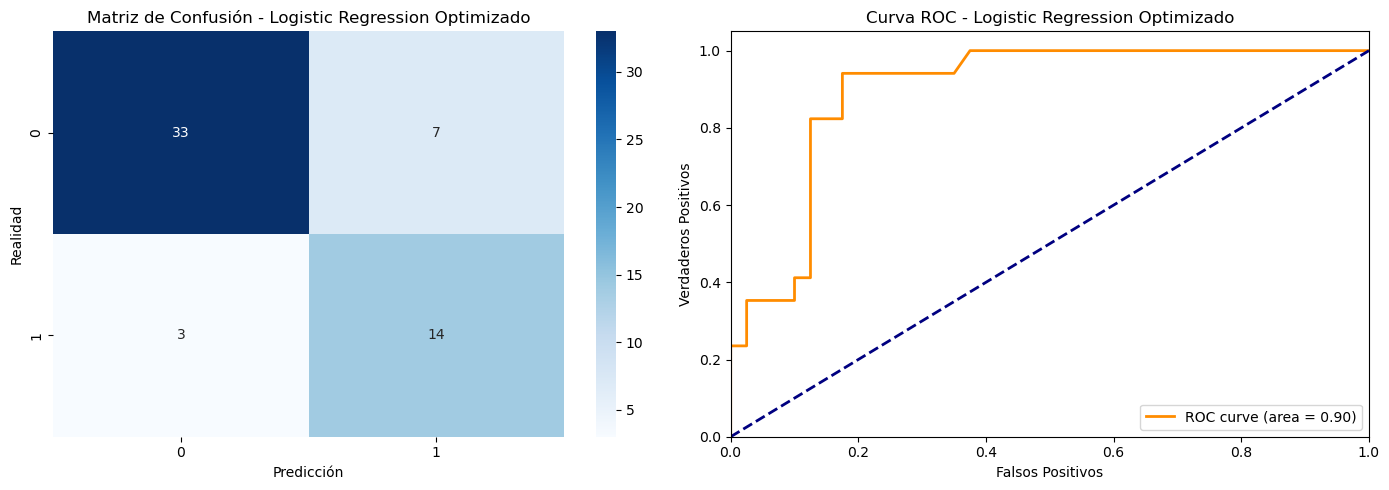

In [41]:
print("OPTIMIZACIÓN REGRESIÓN LOGÍSTICA")

def objective_lr(trial):
    #espacio de busqueda
    c_value = trial.suggest_float('C', 0.001, 100, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    params = {
        'C': c_value,
        'penalty': penalty,
        'solver': 'liblinear',       
        'class_weight': 'balanced',
        'random_state': 42}
    clf = Pipeline([
        ('scaler', StandardScaler()), 
        ('lr', LogisticRegression(**params))])
    
    #CV
    scores = cross_val_score(clf, X_train_final, y_train, cv=10, scoring='roc_auc')
    
    return scores.mean()

#Optuna
study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=200) 
print("MEJORES HIPERPARÁMETROS (Logistic Regression):")
print(study_lr.best_params)

#ENTRENAMIENTO FINAL
best_params_lr = study_lr.best_params
best_params_lr.update({
    'solver': 'liblinear', 
    'class_weight': 'balanced', 
    'random_state': 42})
final_pipeline_lr = Pipeline([
    ('scaler', StandardScaler()), 
    ('lr', LogisticRegression(**best_params_lr))])

#Evaluar
modelo_lr_entrenado, probs_lr = evaluar_modelo_completo(
    "Logistic Regression Optimizado", 
    final_pipeline_lr, 
    X_train_final, y_train, 
    X_test_final, y_test
)
resultados_roc["Logistic Regression"] = probs_lr

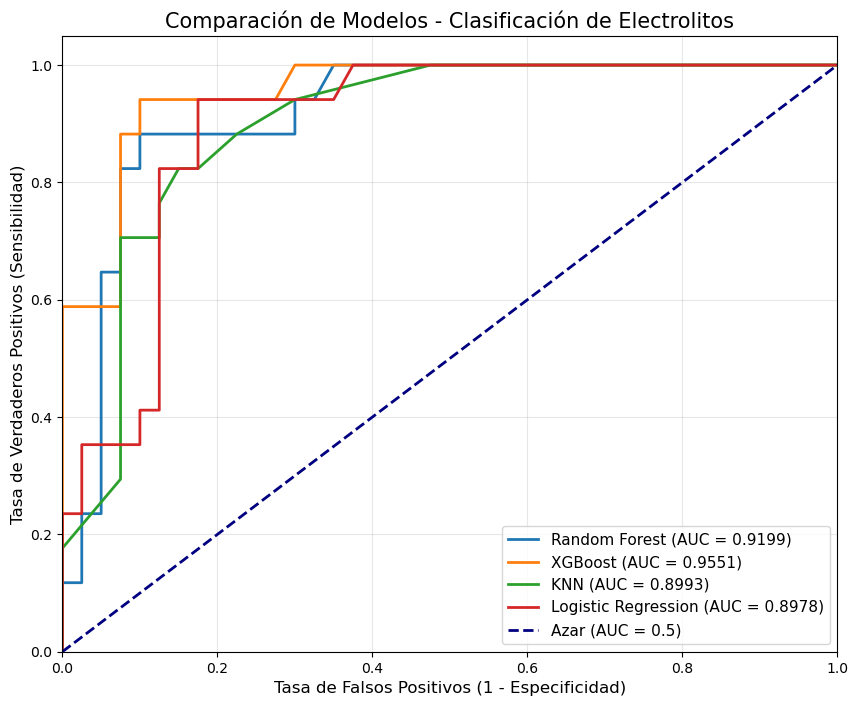

In [43]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for nombre_modelo, y_probs in resultados_roc.items():
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{nombre_modelo} (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.title('Comparación de Modelos - Clasificación de Electrolitos', fontsize=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.savefig("comparación", dpi=300, bbox_inches="tight")

plt.show()